#**DỰ ĐOÁN GIÁ NHÀ**

*   Họ và tên: Hoàng Kim Ngọc
*   MSSV: K225480106053
*   Lớp: K58KTP
*   Học phần: Trí tuệ nhân tạo và học máy

### Mục tiêu: Dự đoán giá nhà bằng mô hình máy học XGBoost.
### Pipeline:


1.   *IMPORT THƯ VIỆN*
2.  *ĐỌC DỮ LIỆU*


1.  *TRỰC QUAN HÓA DỮ LIỆU (EDA)*
2.   *TIỀN XỬ LÝ (PREPROCESSING & FEATURE ENGINEERING)*

1.   *HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH*
2.   *DỰ ĐOÁN TẬP TEST VỚI MÔ HÌNH TỐT NHẤT (XGBoost)*


1.   *TRỰC QUAN HÓA LỖI SAI*






















In [1]:
# 1. IMPORT THƯ VIỆN

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
# 2. ĐỌC DỮ LIỆU

train = pd.read_csv("train.csv", index_col="Id")
test = pd.read_csv("test.csv", index_col="Id")


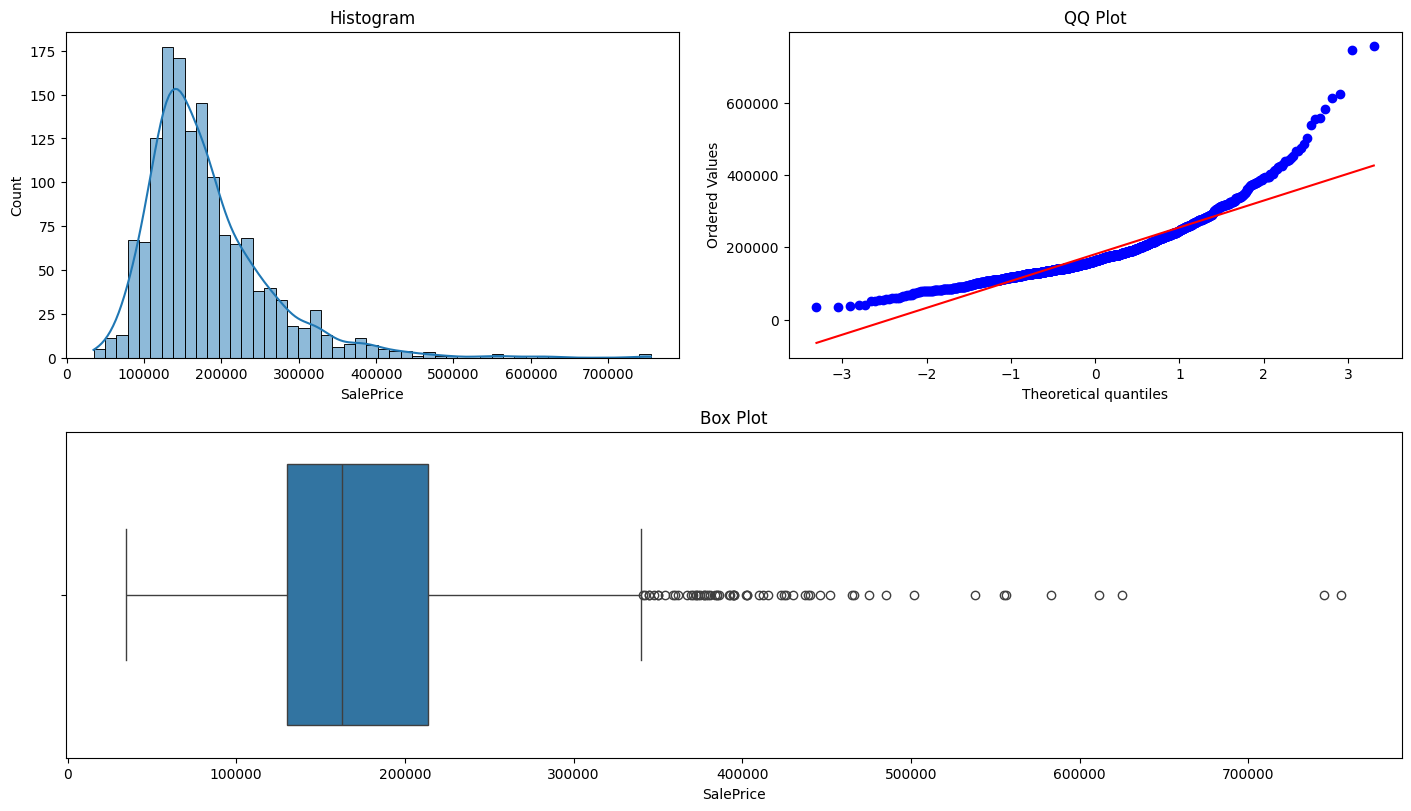

Skewness: 1.8829
Kurtosis: 6.5363



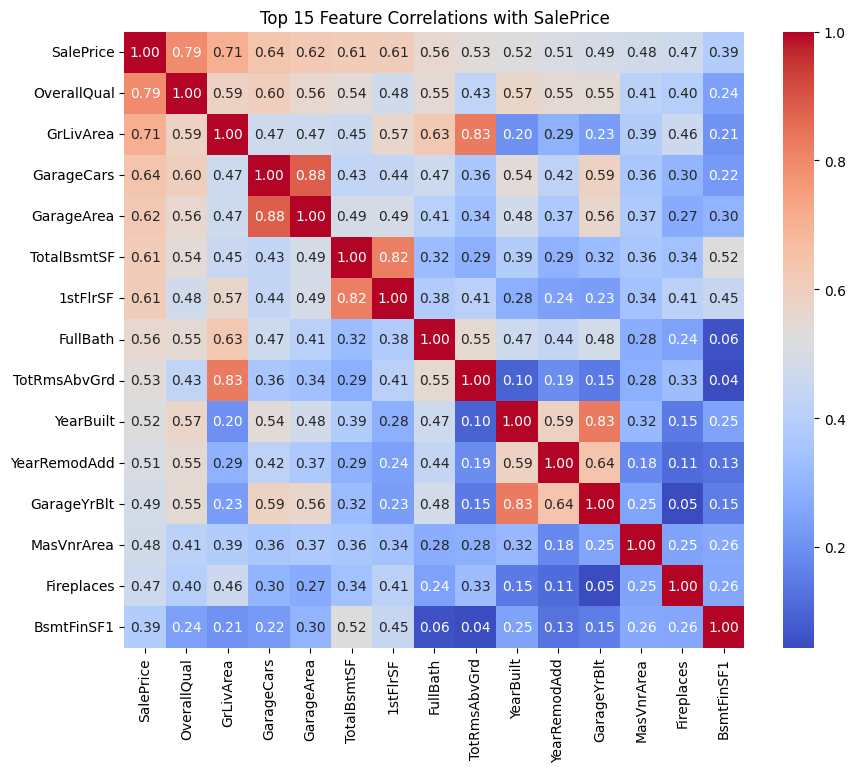

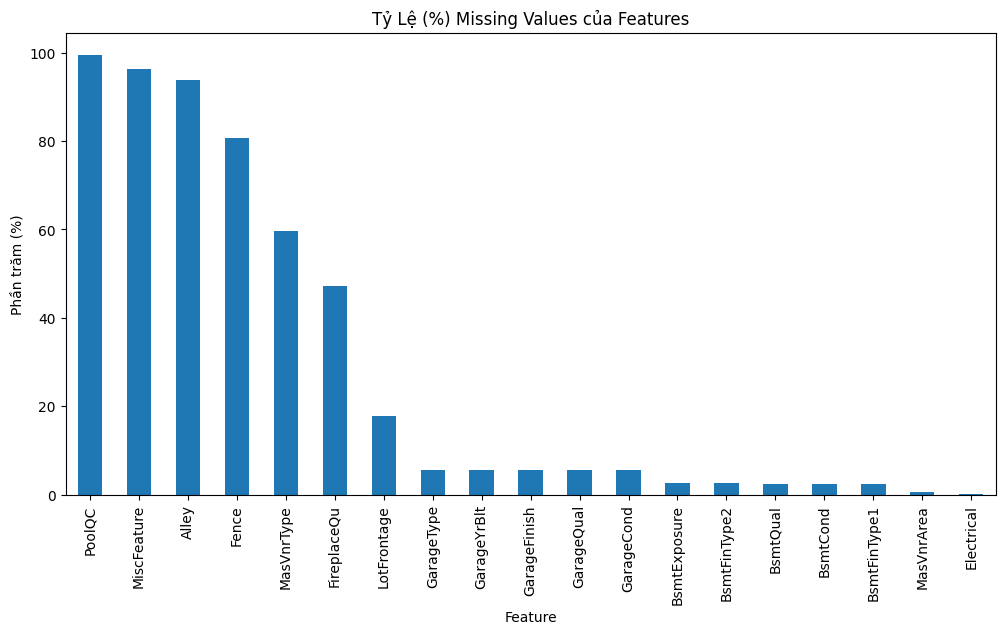

In [3]:
# 3. TRỰC QUAN HÓA DỮ LIỆU (EDA)

# 3.1. Biểu đồ phân phối của SalePrice
def plotting_3_chart(df, feature):
    fig = plt.figure(constrained_layout=True, figsize=(14,8))
    grid = gridspec.GridSpec(2, 2, figure=fig)

    # Histogram
    ax1 = fig.add_subplot(grid[0, 0])
    sns.histplot(df[feature], kde=True, ax=ax1)
    ax1.set_title('Histogram')

    # QQ plot
    ax2 = fig.add_subplot(grid[0, 1])
    stats.probplot(df[feature], plot=ax2)
    ax2.set_title('QQ Plot')

    # Box plot
    ax3 = fig.add_subplot(grid[1, :])
    sns.boxplot(x=df[feature], ax=ax3)
    ax3.set_title('Box Plot')
    plt.show()

plotting_3_chart(train, 'SalePrice')
print(f"Skewness: {train['SalePrice'].skew():.4f}") # độ lệch
print(f"Kurtosis: {train['SalePrice'].kurt():.4f}\n") # độ nhọn

# 3.2. Biểu đồ Heatmap (Top 15 đặc trưng tương quan mạnh nhất)
corr_matrix = train.corr(numeric_only=True)
top_features = corr_matrix["SalePrice"].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10,8))
sns.heatmap(train[top_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top 15 Feature Correlations with SalePrice")
plt.show()

# 3.3. Biểu đồ Missing Values
missing_percent = (train.isnull().sum() / len(train)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(12,6))
missing_percent.plot(kind='bar')
plt.title("Tỷ Lệ (%) Missing Values của Features")
plt.xlabel("Feature")
plt.ylabel("Phần trăm (%)")
plt.xticks(rotation=90)
plt.show()

In [4]:
# 4. TIỀN XỬ LÝ (PREPROCESSING & FEATURE ENGINEERING)

# Xóa Outliers (Chỉ làm trên tập Train)
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index
train = train.drop(outliers)

# Thêm Features mới
def add_features(df):
    df["TotalFlrSF"] = df["1stFlrSF"] + df["2ndFlrSF"]
    df["TotalBath"] = df["FullBath"] + 0.5 * df["HalfBath"]
    return df

train = add_features(train)
test = add_features(test)

# Tách X, y và log transform y
y = np.log1p(train['SalePrice'])
X = train.drop('SalePrice', axis=1)

# Phân loại cột dạng số và chữ
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Tạo bộ xử lý (Pipeline) cho các cột
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])



--- BẢNG SO SÁNH HIỆU SUẤT MÔ HÌNH ---
            Model     RMSE  R2 Score
Linear Regression 0.136674  0.889191
    Random Forest 0.144396  0.876316
              XGB 0.120710  0.913565


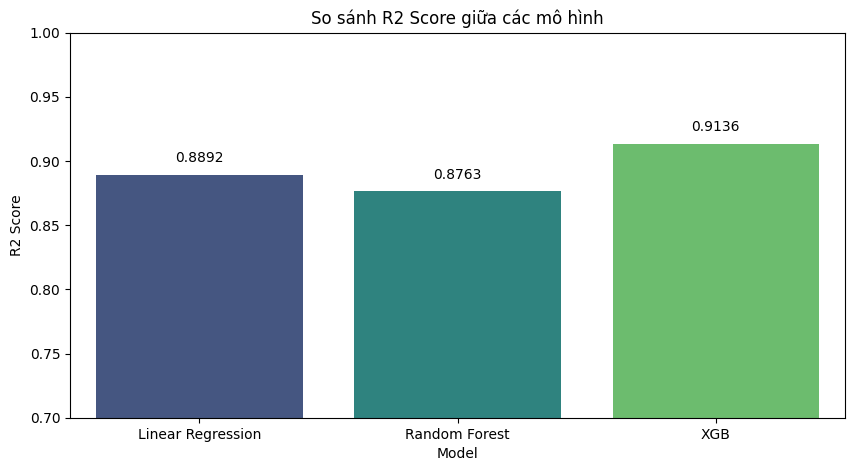

In [5]:
# 5. HUẤN LUYỆN VÀ ĐÁNH GIÁ 3 MÔ HÌNH

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Khai báo danh sách các mô hình cần thử nghiệm
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGB": XGBRegressor(
        n_estimators=1000, learning_rate=0.02, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
        reg_lambda=1, random_state=42
    )
}

# Chạy vòng lặp để train và tính điểm cho từng mô hình
results_list = []
trained_pipelines = {} # Lưu lại pipeline của các mô hình để dùng sau

for model_name, model in models.items():
    # Tạo pipeline hoàn chỉnh cho mô hình hiện tại
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', model)])

    # Train mô hình
    clf.fit(X_train, y_train)
    trained_pipelines[model_name] = clf

    # Dự đoán và Đánh giá
    pred = clf.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2 = r2_score(y_val, pred)

    results_list.append({
        "Model": model_name,
        "RMSE": rmse,
        "R2 Score": r2
    })

# In ra bảng kết quả
results_df = pd.DataFrame(results_list)
print("\n--- BẢNG SO SÁNH HIỆU SUẤT MÔ HÌNH ---")
print(results_df.to_string(index=False))

# Trực quan hóa hiệu suất các mô hình
plt.figure(figsize=(10,5))
sns.barplot(x="Model", y="R2 Score", data=results_df, palette="viridis")
plt.title("So sánh R2 Score giữa các mô hình")
plt.ylim(0.7, 1.0) # Set limit trục Y để dễ nhìn thấy sự khác biệt
for index, row in results_df.iterrows():
    plt.text(index, row['R2 Score'] + 0.01, f"{row['R2 Score']:.4f}", color='black', ha="center")
plt.show()


In [6]:
# 6. DỰ ĐOÁN TẬP TEST VỚI MÔ HÌNH TỐT NHẤT (XGBoost)

# Lấy pipeline của XGBoost (đã train) để dự đoán
best_model_pipeline = trained_pipelines["XGB"]


best_model_pipeline.fit(X, y)

# Dự đoán tập test và biến đổi ngược log1p bằng expm1
pred_test = np.expm1(best_model_pipeline.predict(test))

# Lưu file kết quả
test_result = pd.DataFrame({
    "Id": test.index,
    "SalePrice": pred_test
})

test_result.to_csv("ket_qua.csv", index=False)
print("\nĐã lưu dự đoán của mô hình tốt nhất vào file ket_qua.csv!")


Đã lưu dự đoán của mô hình tốt nhất vào file ket_qua.csv!


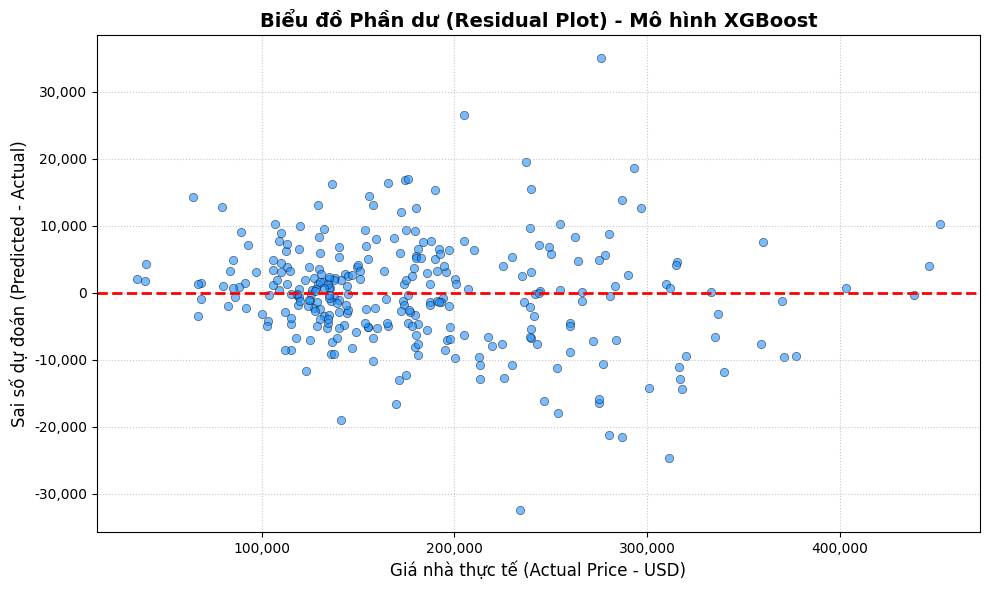

In [7]:
# 7. TRỰC QUAN HÓA LỖI SAI

val_predictions = np.expm1(best_model_pipeline.predict(X_val))
actual_prices = np.expm1(y_val) # y_val cũng đang ở dạng log1p

# Tạo bảng so sánh
error_df = pd.DataFrame({
    'Actual_Price': actual_prices,
    'Predicted_Price': val_predictions
})

# Tính sai số (Error = Giá dự đoán - Giá thực tế)
error_df['Error'] = error_df['Predicted_Price'] - error_df['Actual_Price']
# Tính sai số tuyệt đối để xếp hạng độ lệch
error_df['Absolute_Error'] = error_df['Error'].abs()
# Kích thước biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ Scatter (Phân tán) giữa Giá thực tế và Sai số (Error)
sns.scatterplot(x=error_df['Actual_Price'], y=error_df['Error'],
                alpha=0.6, color='dodgerblue', edgecolor='k')

# Vẽ đường cơ sở y=0 (Đường dự đoán hoàn hảo, sai số = 0)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# Trang trí biểu đồ
plt.title('Biểu đồ Phần dư (Residual Plot) - Mô hình XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Giá nhà thực tế (Actual Price - USD)', fontsize=12)
plt.ylabel('Sai số dự đoán (Predicted - Actual)', fontsize=12)

# Định dạng các con số trên trục tọa độ có dấu phẩy (ví dụ: 100,000 thay vì 100000)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: "{:,}".format(int(y))))

plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()